### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [4]:
# import os
# from dotenv import load_dotenv
# load_dotenv()

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
# os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [9]:
# from langchain_openai import ChatOpenAI
# llm=ChatOpenAI(model="gpt-4o")
from langchain_ollama import ChatOllama
llm = ChatOllama(model="phi4")

llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'phi4', 'created_at': '2026-02-13T09:43:20.4588749Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3298903400, 'load_duration': 166575200, 'prompt_eval_count': 11, 'prompt_eval_duration': 1163999000, 'eval_count': 10, 'eval_duration': 1943692600, 'logprobs': None, 'model_name': 'phi4'}, id='run--019c5662-1f90-76b3-8f18-184bb192d32d-0', usage_metadata={'input_tokens': 11, 'output_tokens': 10, 'total_tokens': 21})

### We Will start With Creating Nodes

In [10]:
def superbot(state:State):
    # return {"messages":[llm_groq.invoke(state['messages'])]}
    return {"messages":[llm.invoke(state['messages'])]}

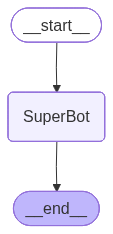

In [12]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [15]:
## Invocation

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"})

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='352490ad-4e11-41fc-b6b4-1d21b2fc028c'),
  AIMessage(content="Hello Krish! It's great to hear that you enjoy cricket. It's a wonderful sport with a rich history and a huge following around the world. Whether you're into watching international matches or playing it yourself, there's always something exciting about cricket.\n\nIf you have any specific questions about cricket—like rules, teams, players, or even how to improve your game—I'd be happy to help. You can also share your favorite teams or memorable moments in cricket if you like!", additional_kwargs={}, response_metadata={'model': 'phi4', 'created_at': '2026-02-13T09:47:23.3379395Z', 'done': True, 'done_reason': 'stop', 'total_duration': 28925745900, 'load_duration': 103632800, 'prompt_eval_count': 20, 'prompt_eval_duration': 1469211400, 'eval_count': 97, 'eval_duration': 27257031300, 'logprobs': None, 'mod

#### Streaming The responses

In [16]:
for event in graph_builder.stream({"messages":"Hello My name is KRish"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='Hi Krishna! How can I assist you today? If you have any questions or need information on a specific topic, feel free to ask. 😊', additional_kwargs={}, response_metadata={'model': 'phi4', 'created_at': '2026-02-13T09:47:53.6067799Z', 'done': True, 'done_reason': 'stop', 'total_duration': 10097023200, 'load_duration': 106505000, 'prompt_eval_count': 16, 'prompt_eval_duration': 1287804400, 'eval_count': 31, 'eval_duration': 8663596200, 'logprobs': None, 'model_name': 'phi4'}, id='run--019c5666-3014-7c70-aa58-46670beae83c-0', usage_metadata={'input_tokens': 16, 'output_tokens': 31, 'total_tokens': 47})]}}


In [17]:
for event in graph_builder.stream({"messages":"Hello My name is KRish"}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hello My name is KRish', additional_kwargs={}, response_metadata={}, id='c7459bd5-815e-4c0a-abff-e478fc01e22e')]}
{'messages': [HumanMessage(content='Hello My name is KRish', additional_kwargs={}, response_metadata={}, id='c7459bd5-815e-4c0a-abff-e478fc01e22e'), AIMessage(content="Hello, Krish! How can I assist you today? Feel free to ask anything or let me know what you'd like to talk about. 😊", additional_kwargs={}, response_metadata={'model': 'phi4', 'created_at': '2026-02-13T10:08:04.8541196Z', 'done': True, 'done_reason': 'stop', 'total_duration': 35221325300, 'load_duration': 23492834100, 'prompt_eval_count': 16, 'prompt_eval_duration': 2386889200, 'eval_count': 31, 'eval_duration': 9218609400, 'logprobs': None, 'model_name': 'phi4'}, id='run--019c5678-494c-7713-8f40-cd216e7ec57d-0', usage_metadata={'input_tokens': 16, 'output_tokens': 31, 'total_tokens': 47})]}


In [18]:
for event in graph_builder.stream({"messages":"Hello My name is KRish"}, stream_mode="updates"):
    print(event)

{'SuperBot': {'messages': [AIMessage(content="Hello Krish! How can I assist you today? Feel free to ask me anything or tell me what you'd like to know. 😊", additional_kwargs={}, response_metadata={'model': 'phi4', 'created_at': '2026-02-13T10:09:47.2195451Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8366286600, 'load_duration': 203645600, 'prompt_eval_count': 16, 'prompt_eval_duration': 559926600, 'eval_count': 29, 'eval_duration': 7573877300, 'logprobs': None, 'model_name': 'phi4'}, id='run--019c567a-420d-7352-bf17-a2d1a03d4365-0', usage_metadata={'input_tokens': 16, 'output_tokens': 29, 'total_tokens': 45})]}}
